# Do Transverse Bunch Tails Produce Luminosity?

## Relevant functions


In [69]:
import numpy as np
from scipy.special import gamma
from matplotlib import pyplot as plt
from scipy.special import hyp2f1

def q_log(x, q):
    """Compute the q-logarithm."""
    if q == 1:
        return np.log(x)
    else:
        return (x**(1 - q) - 1) / (1 - q)


def q_exponential(x, q):
    """Computes the q-exponential function."""
    if q==1:
        return np.exp(x)
    else:
        valid_base = 1 + (1 - q) * x
        valid_base[valid_base < 0] = 0
        return valid_base ** (1 / (1 - q))

def C_q(q):
    """Computes the normalization factor C_q."""
    if  q < 1:
        return (2 * np.sqrt(np.pi) * gamma(1 / (1 - q))) / ((3 - q) * np.sqrt(1 - q) * gamma((3 - q) / (2 * (1 - q))))
    elif q == 1:
        return np.sqrt(np.pi)
    elif 1 < q < 3:
        return (np.sqrt(np.pi) * gamma((3 - q) / (2 * (q - 1)))) / (np.sqrt(q - 1) * gamma(1 / (q - 1)))
    else:
        raise ValueError("q must be in the range (0, 3).")

def q_gaussian(x, q, beta):
    """Computes the q-Gaussian probability density function."""
    if beta<= 0:
        raise ValueError('beta should be positive')
    if q>3:
        raise ValueError('q should be <3.')
    if 1<=q<3:
        return (np.sqrt(beta) / C_q(q)) * q_exponential(-beta * x**2, q)
    if q<1:
        my_limit = 1/np.sqrt(beta*(1-q))
        return np.where(
        (-my_limit <= x) & (x <= my_limit), 
        (np.sqrt(beta) / C_q(q)) * q_exponential(-beta * x**2, q),
        0
    )

def Q_x(x, q, beta):
    return beta*(q-1)*x**2+1

def Q_x_x0(x, x0, q, beta):
    return beta*(3*q-5)*x**2+beta*(6-4*q)*x0**2-1

def A_plus(x, x0, q, beta):
    return hyp2f1(1, (q-2)/(q-1), 1/2, (Q_x(x, q, beta)-Q_x(x0, q, beta))/Q_x(x, q, beta))

def A_minus(x, x0, q, beta):
    return hyp2f1(1, (q-2)/(q-1), -1/2, (Q_x(x, q, beta)-Q_x(x0, q, beta))/Q_x(x, q, beta))

def rho_x_x0(x, x0, q, beta):
    num = Q_x(x0, q, beta)**(1/(1-q)+1/2)*(Q_x_x0(x, x0, q, beta)* A_plus(x, x0, q, beta)+Q_x(x0, q, beta)*A_minus(x, x0, q, beta))
    dem = np.pi*np.sqrt(x0**2-x**2)*Q_x(x, q, beta)
    result = -num/dem
    return np.nan_to_num(result, nan=0.0)
    

Just plotting the 3 models

1 0.5
1.3 0.9090909090909094
1.48 1.785714285714284


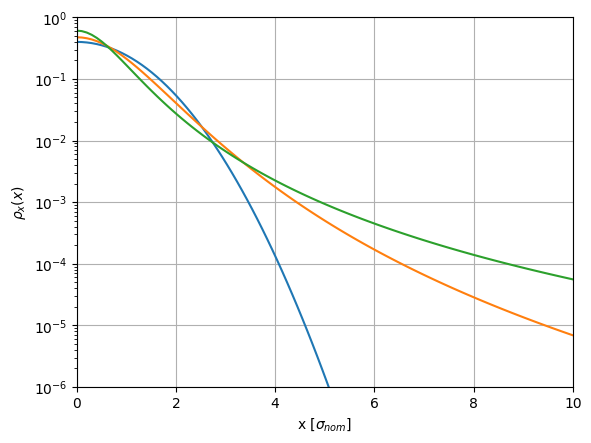

In [87]:
my_q_list = [1, 1.3, 1.48]
for q in my_q_list:
    beta = 1/(5-3*q) # USE THE SAME VARIANCE
    print(q, beta)

    my_range = np.linspace(0,10,100)

    plt.semilogy(my_range, q_gaussian(my_range, q, beta))

plt.xlim(0,10)
plt.ylim(1e-6,1)
plt.xlabel('x [$\\sigma_{nom}$]');
plt.ylabel('$\\rho_x(x)$');
plt.grid()

1 0.5
1.3 0.9090909090909094
1.48 1.785714285714284


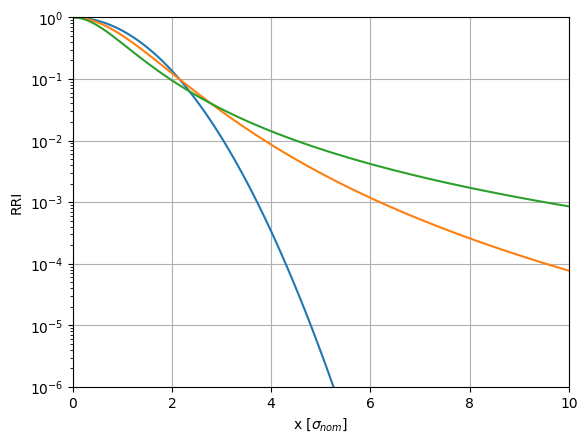

In [80]:
for q in my_q_list:
    beta = 1/(5-3*q) # USE THE SAME VARIANCE
    print(q, beta)
    # from equation 20  of https://meow.elettra.eu/81/pdf/MOPM017.pdf
    my_range = np.linspace(0,10,100)

    plt.semilogy(my_range,q_exponential(-(3-q)*beta/2*my_range**2,(1+q)/(3-q)))

plt.xlim(0,10)
plt.ylim(1e-6,1)
plt.xlabel('x [$\\sigma_{nom}$]');
plt.ylabel('RRI');
plt.grid()

Contrast

1 0.5
1.3 0.9090909090909094
1.48 1.785714285714284


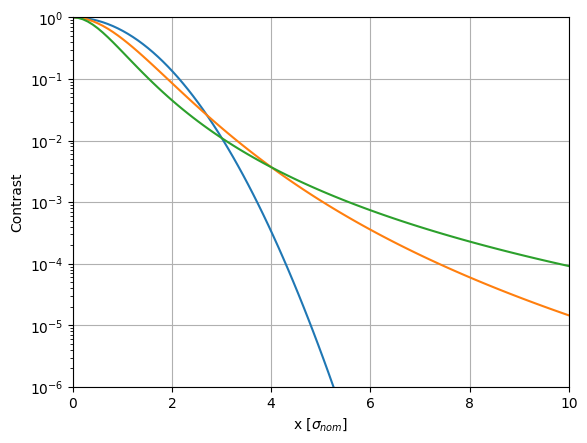

In [88]:
my_range = np.linspace(0,10,100)
for q in my_q_list:
    beta = 1/(5-3*q) # USE THE SAME VARIANCE
    print(q, beta)

    y = q_gaussian(my_range, q, beta)
    plt.semilogy(my_range, y/y[0])

plt.xlim(0,10)
plt.ylim(1e-6,1)
plt.xlabel('x [$\\sigma_{nom}$]');
plt.ylabel('Contrast');
plt.grid()

The CDF of a g-Gaussian is known (e.g. https://en.wikipedia.org/wiki/Q-Gaussian_distribution#:~:text=bounded%20random%20variable.-,Cumulative,-density%20function)

1 0.5
1.3 0.9090909090909094
1.48 1.785714285714284


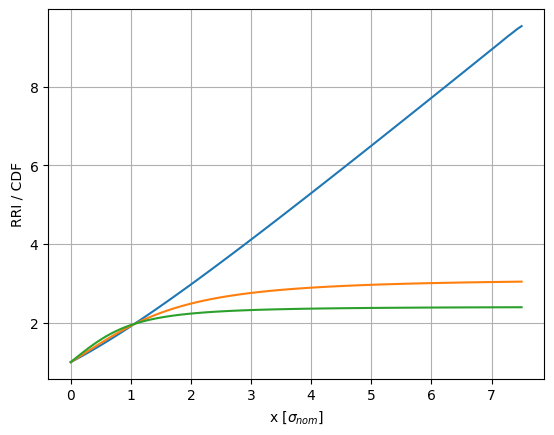

In [127]:
import numpy as np
from scipy.special import hyp2f1, gamma, erf

def cdf_qgaussian(x, q, beta=1.0, atol=1e-10):
    """
    Vectorized CDF of the 1D q-Gaussian distribution.

    Parameters
    ----------
    x : float or array_like
        Evaluation point(s).
    q : float
        Tsallis q parameter.
    beta : float, optional
        Scale parameter (default 1.0).
    atol : float, optional
        Tolerance for treating q ≈ 1 (Gaussian limit).

    Returns
    -------
    F : ndarray
        The cumulative distribution function evaluated at x.
    """
    x = np.asarray(x, dtype=float)
    if beta <= 0:
        raise ValueError("beta must be > 0")
    if q >= 3:
        raise ValueError("q-Gaussian is normalizable only for q < 3")

    # Gaussian limit q → 1
    if np.isclose(q, 1.0, atol=atol):
        return 0.5 * (1.0 + erf(np.sqrt(beta) * x))

    # q < 1 : compact support
    if q < 1.0:
        L = 1.0 / np.sqrt(beta * (1.0 - q))
        F = np.zeros_like(x)

        inside = (x > -L) & (x < L)
        xm = x[inside]

        num = np.sqrt(1.0 - q) * gamma((5.0 - 3.0*q) / (2.0 * (1.0 - q))) * xm * np.sqrt(beta)
        hyp = hyp2f1(0.5, 1.0 / (1.0 - q), 1.5, (1.0 - q) * beta * xm**2)
        den = np.sqrt(np.pi) * gamma((2.0 - q) / (1.0 - q))

        F[inside] = 0.5 + (num * hyp) / den
        F[x >= L] = 1.0
        return F

    # 1 < q < 3 : unbounded support
    num = np.sqrt(q - 1.0) * gamma(1.0 / (q - 1.0)) * x * np.sqrt(beta)
    hyp = hyp2f1(0.5, 1.0 / (q - 1.0), 1.5, -(q - 1.0) * beta * x**2)
    den = np.sqrt(np.pi) * gamma((3.0 - q) / (2.0 * (q - 1.0)))

    return 0.5 + (num * hyp) / den



# plot ration between RRI and cdf_qgaussian

for q in my_q_list:
    beta = 1/(5-3*q) # USE THE SAME VARIANCE
    print(q, beta)  
    my_range = np.linspace(0,7.5,100)
    RRI = q_exponential(-(3-q)*beta/2*my_range**2,(1+q)/(3-q))
    complement_cdf = (1-cdf_qgaussian(my_range, q, beta))*2
    plt.plot(my_range, RRI/complement_cdf)
plt.xlabel('x [$\\sigma_{nom}$]');
plt.ylabel('RRI / CDF');
plt.grid()